# From pixels to coarse data: filtering and reconstruction

A hands-on tutorial for new team members. No neural network, GPU, or JHTDB account is needed.

You will:
1. Read a grayscale image as a 2D array.
2. Calculate box and Gaussian filtering on a small array.
3. Apply both filters to a photo from `images/`.
4. Reproduce the linear-system method in `box_blur_solver.py` to undo box blur.
5. Compare downsampling alone with box filtering + downsampling and Gaussian filtering + downsampling.

Run the cells **in order**. Pause at the prediction questions before running the next cell.

**Setup:** From the repository root, run `uv sync --group extras`, then `uv run jupyter lab`. Open this notebook and use the project Python environment. In VS Code, select that environment as the notebook kernel. Dependencies used here: NumPy, SciPy, Matplotlib, and OpenCV (included in the project's extras).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import convolve

np.set_printoptions(precision=3, suppress=True, linewidth=110)

# Works when Jupyter starts in the repository or experiments directory.
image_dir = None
for parent in (Path.cwd(), *Path.cwd().parents):
    for candidate in (parent / "images", parent / "superresolution_experiments" / "images"):
        if (candidate / "buzz_real.jpg").is_file():
            image_dir = candidate
            break
    if image_dir is not None:
        break
if image_dir is None:
    raise FileNotFoundError("Open this notebook from inside the repository; images/buzz_real.jpg is required.")
print("Using images from:", image_dir)


def show_images(arrays, titles, annotate=False):
    """Shared [0, 1] color scale; nearest display avoids adding visual smoothing."""
    fig, axes = plt.subplots(1, len(arrays), figsize=(4 * len(arrays), 4), squeeze=False)
    for ax, array, title in zip(axes[0], arrays, titles):
        im = ax.imshow(array, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"{title}\nshape={array.shape}")
        if annotate:
            ax.set_xticks(range(array.shape[1]))
            ax.set_yticks(range(array.shape[0]))
            for (row, col), value in np.ndenumerate(array):
                ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                        color="black" if value > 0.55 else "white", fontsize=8)
        else:
            ax.set_axis_off()
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Intensity (shared scale)")
    plt.show()

Using images from: c:\personal-projects\superresolution-nn\superresolution_experiments\images


## 1. An image is an array

We use one grayscale value per pixel: `0` is black, `1` is white. The array indices are `[row, column]`. Grayscale removes the extra color-channel dimension so we can focus on spatial filtering.

The initial resize below simply prepares a manageable teaching image. Later, we explicitly control filtering and downsampling ourselves.

Shape: (128, 128) dtype: float64
Top-left 6 x 6 values:
 [[0.337 0.322 0.239 0.165 0.106 0.102]
 [0.357 0.251 0.153 0.129 0.122 0.122]
 [0.298 0.173 0.094 0.102 0.122 0.129]
 [0.227 0.161 0.102 0.102 0.129 0.114]
 [0.184 0.173 0.153 0.133 0.137 0.106]
 [0.137 0.188 0.176 0.149 0.153 0.153]]


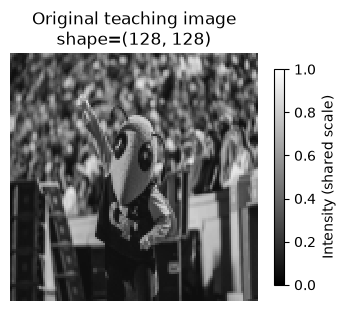

In [2]:
image_name = "buzz_real.jpg"  # Also try buzz_real.jpg or buzz_logo.jpg.
photo_u8 = cv2.imread(str(image_dir / image_name), cv2.IMREAD_GRAYSCALE)
if photo_u8 is None:
    raise FileNotFoundError(image_dir / image_name)
photo = cv2.resize(photo_u8, (128, 128), interpolation=cv2.INTER_AREA).astype(np.float64) / 255.0
print("Shape:", photo.shape, "dtype:", photo.dtype)
print("Top-left 6 x 6 values:\n", photo[:6, :6])
show_images([photo], ["Original teaching image"])

## 2. Box filtering: equal-weight neighbors

A 3 x 3 box kernel gives each of nine neighbors weight `1/9`. At each output pixel, multiply the neighborhood by the kernel and add the products. The kernel weights sum to one.

We will use **zero padding** throughout: values outside the image are treated as zero, and the divisor remains nine at the boundary. This matches `box_blur_solver.py`. It can darken image edges. Reflection and periodic wrapping are other conventions; the main CFD preprocessing uses wrapping. Boundary conventions must match when comparing or undoing filters.

Predict the filtered value at the center of this bright 3 x 3 square and at its corner.

Box kernel:
 [[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]] 
Weight sum: 1.0
Before filtering:
 [[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
After box filtering:
 [[0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.111 0.222 0.333 0.222 0.111 0.   ]
 [0.    0.222 0.444 0.667 0.444 0.222 0.   ]
 [0.    0.333 0.667 1.    0.667 0.333 0.   ]
 [0.    0.222 0.444 0.667 0.444 0.222 0.   ]
 [0.    0.111 0.222 0.333 0.222 0.111 0.   ]
 [0.    0.    0.    0.    0.    0.    0.   ]]


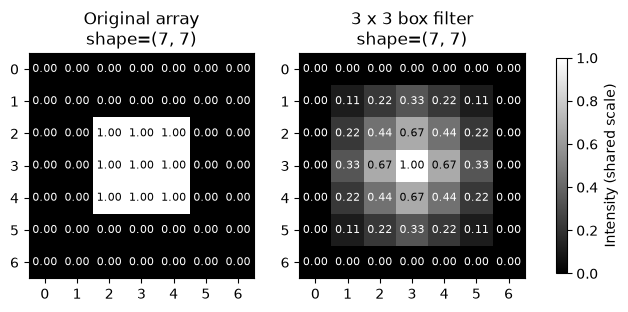

Neighborhood at (2, 2):
 [[0. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]]
Multiply each value by its weight:
 [[0.    0.    0.   ]
 [0.    0.111 0.111]
 [0.    0.111 0.111]]
Sum = 0.4444444444444444 = filtered pixel 0.4444444444444444


In [3]:
def box_kernel(size):
    if size < 1 or size % 2 != 1:
        raise ValueError("Use a positive odd kernel size.")
    return np.ones((size, size), dtype=np.float64) / size**2


def apply_filter(image, kernel):
    # Keep fractional values: filtering integer arrays can discard precision.
    return convolve(np.asarray(image, dtype=np.float64), kernel, mode="constant", cval=0.0)


toy = np.zeros((7, 7), dtype=np.float64)
toy[2:5, 2:5] = 1.0
box3 = box_kernel(3)
toy_box = apply_filter(toy, box3)
print("Box kernel:\n", box3, "\nWeight sum:", box3.sum())
print("Before filtering:\n", toy)
print("After box filtering:\n", toy_box)
show_images([toy, toy_box], ["Original array", "3 x 3 box filter"], annotate=True)

row, col = 2, 2
patch = toy[row-1:row+2, col-1:col+2]
print("Neighborhood at (2, 2):\n", patch)
print("Multiply each value by its weight:\n", patch * box3)
print("Sum =", (patch * box3).sum(), "= filtered pixel", toy_box[row, col])
assert np.isclose(toy_box[row, col], 4 / 9)
assert np.isclose(toy_box[3, 3], 1.0)

## 3. Gaussian filtering: nearby pixels get more weight

For offsets `(x, y)` from the kernel center, start with weights proportional to:

`exp(-(x² + y²) / (2 sigma²))`

Then divide by the sum of all weights. `sigma` is measured in pixels and controls the spread. A larger sigma spreads weight farther out, provided the kernel is large enough. A Gaussian has infinite support mathematically; our finite kernel truncates it.

Here we use the same 3 x 3 footprint as the box kernel so you can compare the weights directly. Gaussian filtering still computes a weighted sum; only the weights change.

Gaussian kernel:
 [[0.057 0.125 0.057]
 [0.125 0.272 0.125]
 [0.057 0.125 0.057]] 
Weight sum: 1.0
After Gaussian filtering:
 [[0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.057 0.182 0.239 0.182 0.057 0.   ]
 [0.    0.182 0.579 0.761 0.579 0.182 0.   ]
 [0.    0.239 0.761 1.    0.761 0.239 0.   ]
 [0.    0.182 0.579 0.761 0.579 0.182 0.   ]
 [0.    0.057 0.182 0.239 0.182 0.057 0.   ]
 [0.    0.    0.    0.    0.    0.    0.   ]]
At (2, 2): weighted sum = 0.5791297277546915


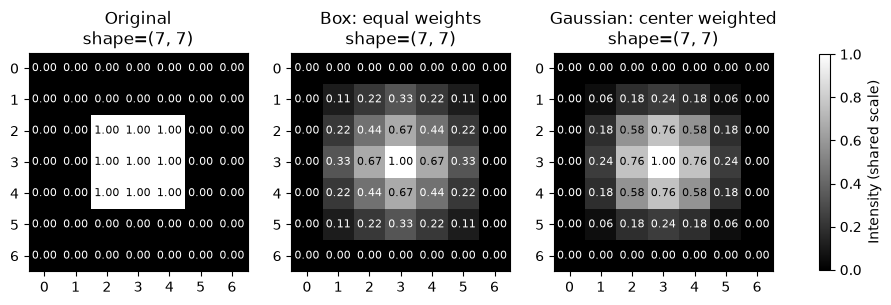

In [4]:
def gaussian_kernel(size, sigma):
    if size < 1 or size % 2 != 1 or sigma <= 0:
        raise ValueError("Use a positive odd size and positive sigma.")
    offsets = np.arange(-(size // 2), size // 2 + 1, dtype=np.float64)
    x, y = np.meshgrid(offsets, offsets)
    weights = np.exp(-(x*x + y*y) / (2 * sigma*sigma))
    return weights / weights.sum()


gauss3 = gaussian_kernel(3, sigma=0.8)
toy_gaussian = apply_filter(toy, gauss3)
print("Gaussian kernel:\n", gauss3, "\nWeight sum:", gauss3.sum())
print("After Gaussian filtering:\n", toy_gaussian)
print("At (2, 2): weighted sum =", (patch * gauss3).sum())
show_images([toy, toy_box, toy_gaussian],
            ["Original", "Box: equal weights", "Gaussian: center weighted"], annotate=True)
assert np.isclose(gauss3.sum(), 1.0)
assert np.isclose(toy_gaussian[2, 2], (patch * gauss3).sum())

## 4. Filter a real image

The following filters both have a 7 x 7 footprint, but they do not have identical smoothing strength. Equal footprint does not make two filters equivalent.

Look at sharp edges and fine texture. Filtering changes values while preserving the array's shape. The zoomed numerical patches below are extracted **after filtering the full image**, so their edges are not treated as new image boundaries.

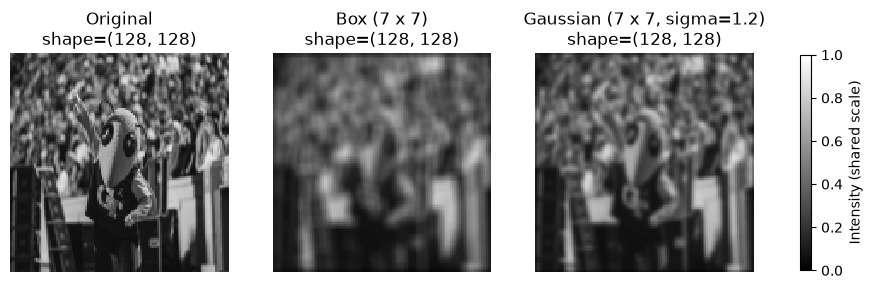

Original, rows 60:66 and columns 60:66:
[[0.463 0.29  0.239 0.243 0.251 0.251]
 [0.384 0.263 0.227 0.247 0.247 0.263]
 [0.361 0.259 0.239 0.243 0.247 0.263]
 [0.333 0.22  0.235 0.255 0.255 0.259]
 [0.243 0.22  0.239 0.235 0.255 0.267]
 [0.224 0.212 0.251 0.251 0.247 0.263]]

Box, rows 60:66 and columns 60:66:
[[0.445 0.387 0.334 0.289 0.25  0.23 ]
 [0.43  0.372 0.32  0.279 0.251 0.24 ]
 [0.414 0.357 0.306 0.271 0.254 0.25 ]
 [0.398 0.341 0.293 0.262 0.256 0.26 ]
 [0.385 0.328 0.282 0.257 0.257 0.267]
 [0.371 0.316 0.272 0.255 0.259 0.271]]

Gaussian, rows 60:66 and columns 60:66:
[[0.448 0.347 0.279 0.253 0.251 0.251]
 [0.416 0.322 0.267 0.25  0.252 0.258]
 [0.389 0.301 0.258 0.248 0.253 0.261]
 [0.362 0.283 0.25  0.247 0.254 0.263]
 [0.334 0.266 0.245 0.247 0.255 0.264]
 [0.309 0.253 0.242 0.248 0.257 0.267]]



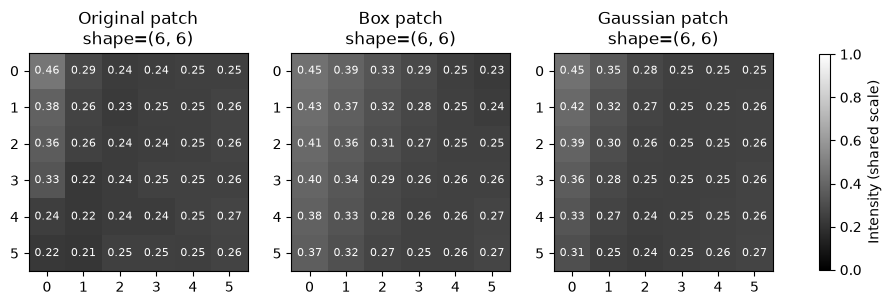

In [5]:
box7 = box_kernel(7)
gauss7 = gaussian_kernel(7, sigma=1.2)
photo_box = apply_filter(photo, box7)
photo_gaussian = apply_filter(photo, gauss7)
show_images([photo, photo_box, photo_gaussian],
            ["Original", "Box (7 x 7)", "Gaussian (7 x 7, sigma=1.2)"])

region = np.s_[60:66, 60:66]
for label, array in [("Original", photo), ("Box", photo_box), ("Gaussian", photo_gaussian)]:
    print(f"{label}, rows 60:66 and columns 60:66:\n{array[region]}\n")
show_images([photo[region], photo_box[region], photo_gaussian[region]],
            ["Original patch", "Box patch", "Gaussian patch"], annotate=True)

## 5. Undo box blur with the existing solver's logic

This section follows `box_blur_solver.py`:

1. Flatten an `n x n` image into a vector `f` of length `N = n²`.
2. Build a matrix `A` of shape `(N, N)`. Each row contains the averaging weights for one output pixel.
3. Blur with `g = A @ f`.
4. Attempt recovery with `np.linalg.solve(A, g)`.

Use **16 x 16** here: a dense matrix grows as `n⁴` entries, so this demonstration should stay small. We use a 3 x 3 kernel with this size for a nonsingular teaching example. Other size/kernel combinations can be singular.

There is **no downsampling yet**. We retain every blurred pixel and full floating-point precision. Solving this favorable example does not mean arbitrary blur can always be reversed.

A shape: (4096, 4096) f shape: (4096,) g shape: (4096,)
Corner output: fewer nonzero weights, with zero padding outside:
[[0.111 0.111 0.    0.   ]
 [0.111 0.111 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]
Condition number (large means sensitive to perturbations): 11434.613926607426
Maximum absolute reconstruction error: 1.6056600493641326e-14


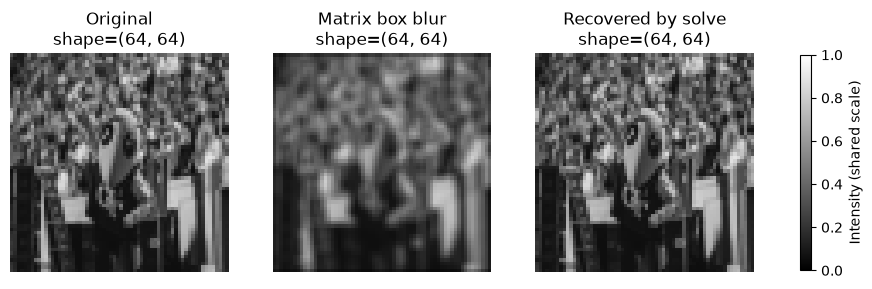

Original top-left 4 x 4:
 [[0.317 0.172 0.113 0.112]
 [0.215 0.1   0.124 0.102]
 [0.171 0.153 0.137 0.108]
 [0.15  0.14  0.215 0.123]]
Blurred top-left 4 x 4:
 [[0.089 0.115 0.08  0.103]
 [0.125 0.167 0.124 0.159]
 [0.103 0.156 0.133 0.177]
 [0.089 0.149 0.151 0.192]]
Recovered top-left 4 x 4:
 [[0.317 0.172 0.113 0.112]
 [0.215 0.1   0.124 0.102]
 [0.171 0.153 0.137 0.108]
 [0.15  0.14  0.215 0.123]]


In [6]:
def build_box_matrix(n, kernel_size):
    box_kernel(kernel_size)  # Validate the size.
    A = np.zeros((n*n, n*n), dtype=np.float64)
    pad = kernel_size // 2
    for i in range(n):
        for j in range(n):
            row = i*n + j
            for di in range(-pad, pad + 1):
                for dj in range(-pad, pad + 1):
                    ni, nj = i + di, j + dj
                    if 0 <= ni < n and 0 <= nj < n:
                        A[row, ni*n + nj] += 1.0 / kernel_size**2
    return A


n = 64
small = cv2.resize(photo, (n, n), interpolation=cv2.INTER_AREA)
A = build_box_matrix(n, kernel_size=3)
f = small.flatten()
g = A @ f
blurred = g.reshape(n, n)
np.testing.assert_allclose(blurred, apply_filter(small, box3), atol=1e-12)
print("A shape:", A.shape, "f shape:", f.shape, "g shape:", g.shape)
print("Corner output: fewer nonzero weights, with zero padding outside:")
print(A[0].reshape(n, n)[:4, :4])
print("Condition number (large means sensitive to perturbations):", np.linalg.cond(A))

recovered = None
try:
    recovered = np.linalg.solve(A, g).reshape(n, n)
except np.linalg.LinAlgError:
    print("This configuration is singular; an exact unique inverse is unavailable.")

if recovered is not None:
    print("Maximum absolute reconstruction error:", np.max(np.abs(recovered - small)))
    np.testing.assert_allclose(recovered, small, atol=1e-9)
    show_images([small, blurred, recovered], ["Original", "Matrix box blur", "Recovered by solve"])
    print("Original top-left 4 x 4:\n", small[:4, :4])
    print("Blurred top-left 4 x 4:\n", blurred[:4, :4])
    print("Recovered top-left 4 x 4:\n", recovered[:4, :4])

### What if the blurred values are slightly inaccurate?

Now perturb the blurred measurements by a small amount. An inverse can amplify that error. Measurement noise and storage rounding are reasons a mathematically invertible filter can still be hard to undo in practice.

The display uses the same [0, 1] scale as before. Out-of-range reconstructed values saturate in the plot, but we do **not** clip them when computing errors.

Measurement noise RMSE: 0.001995
Recovered image RMSE:  0.314867
Error amplification: 157.81x
Recovered range: -1.1918921799374764 1.6097537224004295


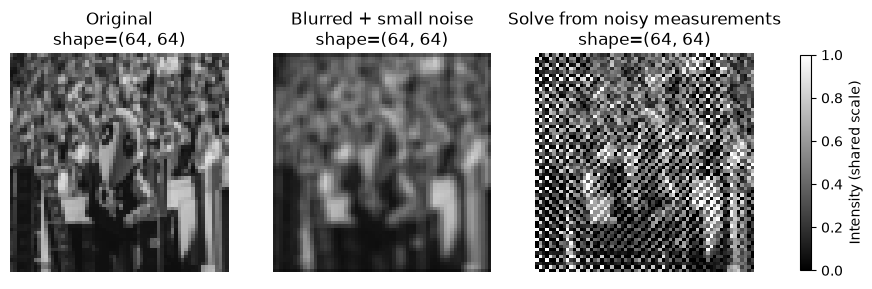

In [7]:
if recovered is not None:
    rng = np.random.default_rng(42)
    noise = rng.normal(0.0, 0.002, size=g.shape)
    noisy_g = g + noise
    noisy_recovered = np.linalg.solve(A, noisy_g).reshape(n, n)
    measurement_rmse = np.sqrt(np.mean(noise**2))
    reconstruction_rmse = np.sqrt(np.mean((noisy_recovered - small)**2))
    print(f"Measurement noise RMSE: {measurement_rmse:.6f}")
    print(f"Recovered image RMSE:  {reconstruction_rmse:.6f}")
    print(f"Error amplification: {reconstruction_rmse / measurement_rmse:.2f}x")
    print("Recovered range:", noisy_recovered.min(), noisy_recovered.max())
    show_images([small, noisy_g.reshape(n, n), noisy_recovered],
                ["Original", "Blurred + small noise", "Solve from noisy measurements"])

## 6. Filtering + downsampling

Filtering mixes nearby values. Downsampling changes how many values we keep. In this notebook, `image[::step, ::step]` keeps one pixel every `step` rows and columns, starting at index zero. It does not average anything by itself.

First inspect the small numerical example. Then compare the photo. The plots occupy similar screen space, but the coarse arrays genuinely contain fewer pixels.

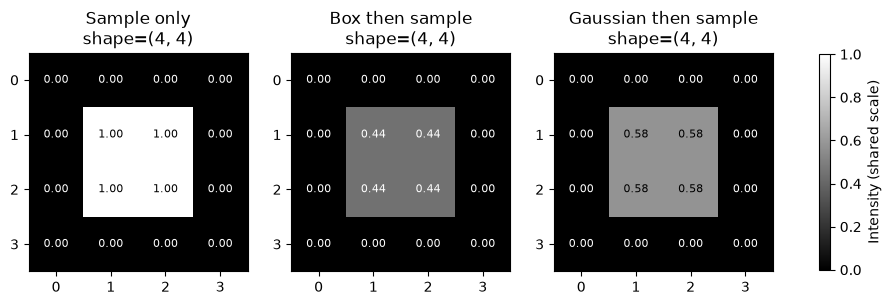

Original -> keep every 2nd row/column:
[[0. 0. 0. 0.]
 [0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [0. 0. 0. 0.]]

Box filtered -> keep every 2nd row/column:
[[0.    0.    0.    0.   ]
 [0.    0.444 0.444 0.   ]
 [0.    0.444 0.444 0.   ]
 [0.    0.    0.    0.   ]]

Gaussian filtered -> keep every 2nd row/column:
[[0.    0.    0.    0.   ]
 [0.    0.579 0.579 0.   ]
 [0.    0.579 0.579 0.   ]
 [0.    0.    0.    0.   ]]



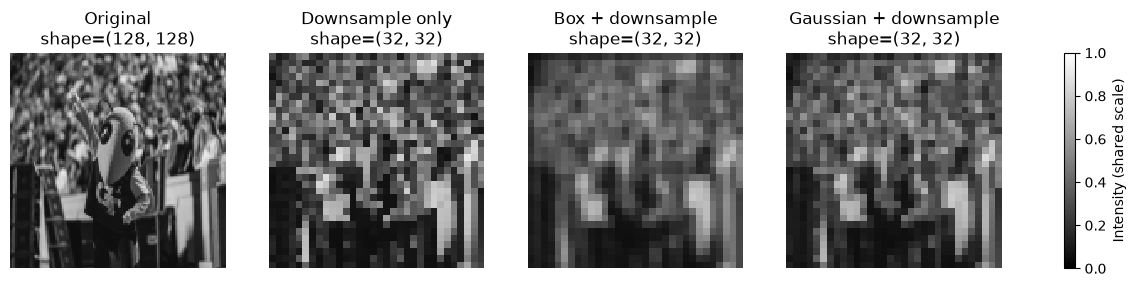

(128, 128) -> (32, 32); 16384 -> 1024 values


In [8]:
toy_step = 2
show_images([toy[::toy_step, ::toy_step], toy_box[::toy_step, ::toy_step],
             toy_gaussian[::toy_step, ::toy_step]],
            ["Sample only", "Box then sample", "Gaussian then sample"], annotate=True)
for label, array in [("Original", toy), ("Box filtered", toy_box), ("Gaussian filtered", toy_gaussian)]:
    print(f"{label} -> keep every {toy_step}nd row/column:\n{array[::toy_step, ::toy_step]}\n")

step = 4
coarse_raw = photo[::step, ::step]
coarse_box = photo_box[::step, ::step]
coarse_gaussian = photo_gaussian[::step, ::step]
show_images([photo, coarse_raw, coarse_box, coarse_gaussian],
            ["Original", "Downsample only", "Box + downsample", "Gaussian + downsample"])
print(f"{photo.shape} -> {coarse_box.shape}; {photo.size} -> {coarse_box.size} values")
assert coarse_box.shape == (32, 32)

### Why not just skip pixels? Aliasing

A checkerboard alternates between zero and one. Sampling every second pixel at the same alignment keeps only zeros, creating a false constant signal. Starting one pixel later would keep only ones.

Filtering suppresses rapid variation before sampling. It does not guarantee perfect anti-aliasing for every kernel and sampling factor. Ignore the dark outer boundary here, which comes from our explicit zero-padding convention.

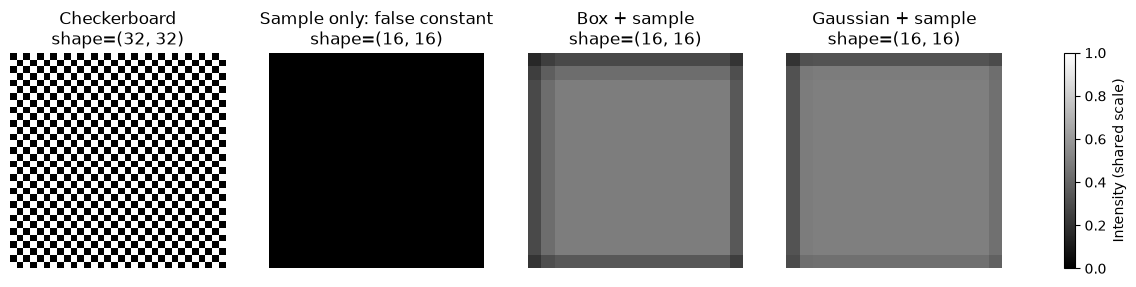

True checkerboard mean: 0.5
Unfiltered coarse mean: 0.0
Filtered interior means: 0.48979591836734726 0.49999964700690036


In [9]:
checker = (np.indices((32, 32)).sum(axis=0) % 2).astype(np.float64)
checker_box = apply_filter(checker, box_kernel(7))[::2, ::2]
checker_gaussian = apply_filter(checker, gaussian_kernel(9, 1.3))[::2, ::2]
show_images([checker, checker[::2, ::2], checker_box, checker_gaussian],
            ["Checkerboard", "Sample only: false constant", "Box + sample", "Gaussian + sample"])
print("True checkerboard mean:", checker.mean())
print("Unfiltered coarse mean:", checker[::2, ::2].mean())
print("Filtered interior means:", checker_box[3:-3, 3:-3].mean(),
      checker_gaussian[3:-3, 3:-3].mean())

## 7. Why the box solver cannot simply undo downsampling

For the 16 x 16 image, box blur alone gives 256 equations for 256 unknown pixel values. Sampling every second row/column keeps only 64 measurements for 256 unknowns. The combined operator is a **rectangular matrix**, not a square invertible one.

A least-squares solver can select a solution, but the measurements alone cannot identify the original uniquely. Below, it selects the minimum-norm solution. A small measurement residual does not imply an accurate reconstructed image.

Combined blur + sample matrix: (1024, 4096)
Rank: 1024 Unconstrained dimensions: 3072
Measurement residual: 2.4753522472054027e-14
Image RMSE: 0.1777828068845846


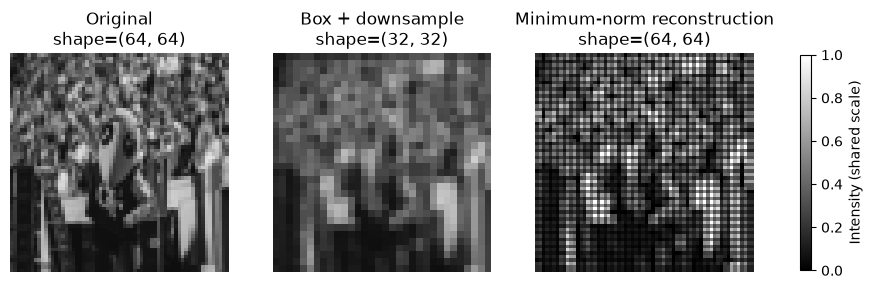

In [10]:
kept_indices = np.arange(n*n).reshape(n, n)[::2, ::2].ravel()
B = A[kept_indices, :]
coarse_measurements = B @ f
np.testing.assert_allclose(coarse_measurements.reshape(n//2, n//2), blurred[::2, ::2])
estimate, _, rank, _ = np.linalg.lstsq(B, coarse_measurements, rcond=None)
print("Combined blur + sample matrix:", B.shape)
print("Rank:", rank, "Unconstrained dimensions:", B.shape[1] - rank)
print("Measurement residual:", np.linalg.norm(B @ estimate - coarse_measurements))
print("Image RMSE:", np.sqrt(np.mean((estimate - f)**2)))
show_images([small, coarse_measurements.reshape(n//2, n//2), estimate.reshape(n, n)],
            ["Original", "Box + downsample", "Minimum-norm reconstruction"])

## 8. Connect this to our superresolution project

Our main pipeline applies the same idea to **3D velocity arrays**, with three components per grid point instead of one grayscale intensity. The maintained preprocessing applies Gaussian filtering to each velocity component, then keeps every fourth point along each spatial axis. It uses **periodic wrapping**, unlike this tutorial's zero padding.

For `upsample_cnn`, a training pair is:

- **Input:** filtered and downsampled velocity.
- **Target:** the original detailed velocity field.

A neural network learns patterns across training examples to estimate missing information. It cannot make the inverse unique or guarantee that every recovered detail is true. We evaluate on held-out examples and compare against interpolation.

### Try it yourself

1. Change the toy square into a single bright pixel. Predict the box and Gaussian outputs.
2. Change Gaussian `sigma` and kernel size. Watch how the weights change.
3. Try `buzz_logo.jpg`. Which edges change most?
4. Change the noise level in the inverse example. Does reconstruction error grow?
5. Change the photo downsampling step to 2 or 8 (and update the shape assertion). How many values remain?
6. Explain the difference between filtering, downsampling, and reconstructing without using the word "resize."

**Before moving on:** be able to explain one filtered pixel as a weighted sum, why a boundary rule is necessary, and why matching coarse measurements does not guarantee the correct fine image.